# Test

#### imports

In [1]:
from transfer_learning_model import TransferLearningModel, DroneLoss, train, predict, predict_locations, validate, convert_preds_to_mAP_input_format, convert_ground_truth_to_mAP_input_format, calculate_detection_metrics, calculate_metrics
from DroneDataset import DroneDataset, read_annotations, add_padding_fn
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from preprocess import preprocess
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import cv2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
best_model_path = "experiment10_model\\model_0.pt"

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

best_model = TransferLearningModel(
    detection_layers=checkpoint["detection_layers"],
    activation_func=checkpoint["activation_func"],
    dropout_rate=checkpoint["dropout_rate"]
)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)

In [6]:
test_set = DroneDataset(*read_annotations("test_max_size256"))

In [7]:
test_loader = DataLoader(test_set,
                         batch_size=16,
                         shuffle=False,
                         num_workers=4,
                         pin_memory=True,
                         collate_fn=add_padding_fn)

In [8]:
test_bbox_preds, test_bbox_labels = predict(best_model, test_loader)

In [9]:
test_metric_pred = convert_preds_to_mAP_input_format(test_bbox_preds)
test_metric_ground_truth = convert_ground_truth_to_mAP_input_format(test_bbox_labels)

In [10]:
test_metric = MeanAveragePrecision(iou_thresholds=[0.5])
test_metric.update(test_metric_pred, test_metric_ground_truth)
test_result = test_metric.compute()

test_mAP50 = test_result["map_50"].item()

In [12]:
objectness_threshold = 0.50

In [13]:
test_TP, test_FP, test_FN = calculate_detection_metrics(test_bbox_preds, test_bbox_labels, 0.5, objectness_threshold)

test_precision, test_recall, test_f1 = calculate_metrics(test_TP, test_FP, test_FN)


In [15]:
print("============ Test Results =============")
print(f"Test TP: {test_TP}")
print(f"Test FP: {test_FP}")
print(f"Test FN: {test_FN}")
print()
print(f"Test precision: {test_precision}")
print(f"Test recall: {test_recall}")
print(f"Test f1: {test_f1}")
print()
print(f"Test mAP50: {test_mAP50}")

============ Test Results =============
Test TP: 1065
Test FP: 446
Test FN: 965

Test precision: 0.7048312375909993
Test recall: 0.5246305418719212
Test f1: 0.6015249929398474

Test mAP50: 0.4771386384963989


In [29]:
import numpy as np
import torchvision.transforms as T

def draw_bbox(model, image_path, objectness_threshold):

    # preprocess image, turn image into tensor
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_h, image_w = image.shape[:2]

    image = image.astype(np.float32) / 255.0

    image = image.transpose(2, 0, 1)

    image_tensor = torch.from_numpy(image)

    normalize_fn = T.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225]
                            )

    image_tensor = normalize_fn(image_tensor)

    # predict
    predictions = predict_locations(model, image_tensor, objectness_threshold)

    # draw bboxes
    image_original = cv2.imread(image_path)
    image_original = cv2.cvtColor(image_original, cv2.COLOR_BGR2RGB)

    for pred in predictions:
        bbox = pred["bbox"]
        confidence = pred["confidence"]
        confidence_text = f"{confidence:.2f}"

        x = int(bbox[0])
        y = int(bbox[1])
        w = int(bbox[2])
        h = int(bbox[3])
        cv2.rectangle(image_original, (x, y), ((x + w), (y + h)), (255, 0, 0), thickness=2)
        cv2.putText(image_original, confidence_text, ((x + 2), (y - 2)), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.7, color=(255, 0, 0), thickness=1)

    plt.imshow(image_original)
    plt.axis("off")
    plt.show()


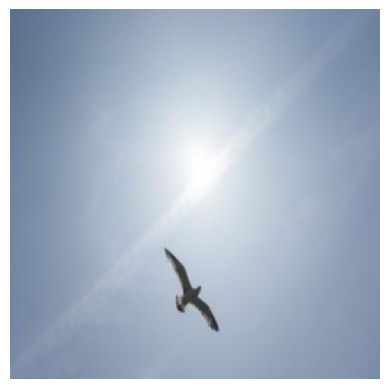

In [30]:
draw_bbox(best_model, "demo_images\\-_jpeg_jpg.rf.q4kuvcM3awwnIBRFn6Xk.jpg", 0.5)

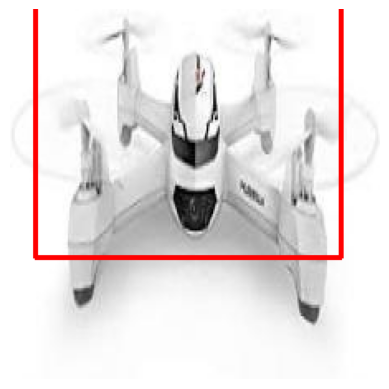

In [31]:
draw_bbox(best_model, "demo_images\\1-574-_jpeg_jpg.rf.EYIVq1YV7dLmrXje6rfN.jpg", 0.5)

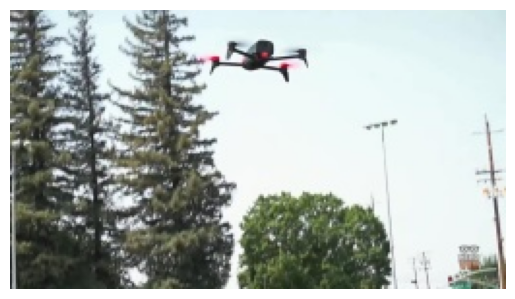

In [33]:
draw_bbox(best_model, "demo_images\\00003_jpg.rf.W2vE1OJDqmMXZ20sqr8D.jpg", 0.5)

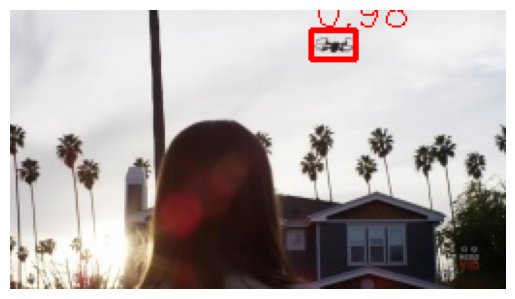

In [34]:
draw_bbox(best_model, "demo_images\\00004_jpg.rf.2YRkVirGXCPLP8oZiNDO.jpg", 0.5)

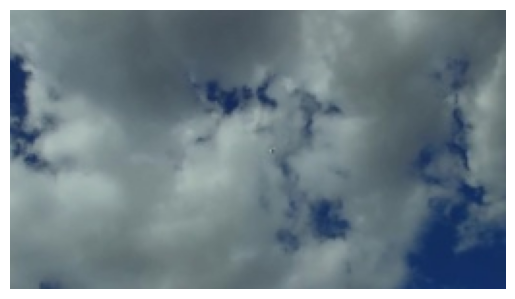

In [35]:
draw_bbox(best_model, "demo_images\\00005_jpg.rf.6Usndn4PYf45CSnPcY69.jpg", 0.5)

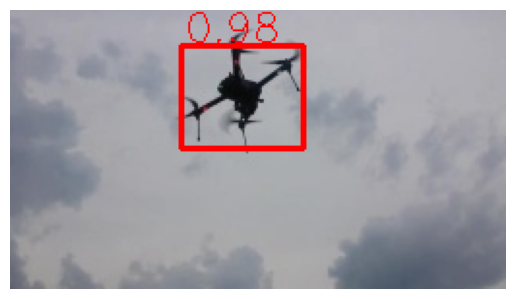

In [36]:
draw_bbox(best_model, "demo_images\\00013_jpg.rf.5DQGdCR5KE9y58WrJxAe.jpg", 0.5)

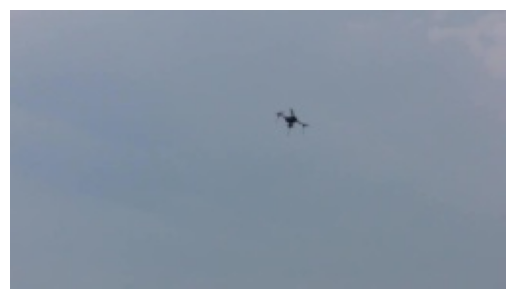

In [37]:
draw_bbox(best_model, "demo_images\\00020_jpg.rf.yBOcPjIRKgeMhaIT5wH0.jpg", 0.5)

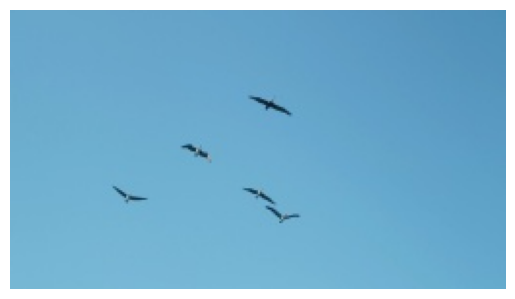

In [39]:
draw_bbox(best_model, "demo_images\\bird1_mp4-0001_jpg.rf.Hvctv0WfHXxgC7J93H6A.jpg", 0.5)

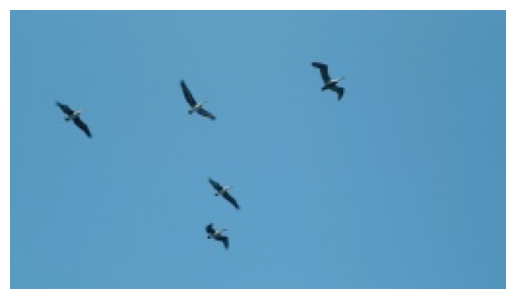

In [40]:
draw_bbox(best_model, "demo_images\\bird1_mp4-0050_jpg.rf.QItIdzFRysNK1LpSRb5Q.jpg", 0.5)

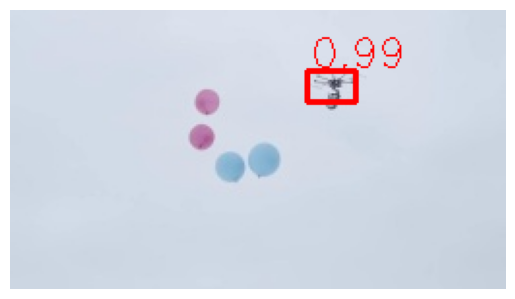

In [41]:

draw_bbox(best_model, "demo_images\\00229_jpg.rf.r1QlPUtD2LHybQgoBvbR.jpg", 0.5)